# Importing libraries

In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm

# Data loading

In [225]:
df = pd.read_csv("AirbnbEurope.csv")

# Filling missing values

In [226]:
# Missing values here occur when 'number_of_reviews' is 0, so 0 is factually correct.
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Ratings are often skewed; the median provides a "typical" score without being pulled by outliers.
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())

# Fill bathrooms, bedrooms, beds nulls based on 'accommodates' group median, then global median
df['bathrooms'] = df.groupby('accommodates')['bathrooms'].transform(lambda x: x.fillna(x.median()))
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())

df['bedrooms'] = df.groupby('accommodates')['bedrooms'].transform(lambda x: x.fillna(x.median()))
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

df['beds'] = df.groupby('accommodates')['beds'].transform(lambda x: x.fillna(x.median()))
df['beds'] = df['beds'].fillna(df['beds'].median())

# Fill price using median
df['price'] = df['price'].fillna(df['price'].median())

# Since log_price is a mathematical derivative of price, we recalculate it to ensure consistency.
df['log_price'] = np.log1p(df['price'])

# Fill Host Info (Small number of missing values)
df['host_since'] = df['host_since'].fillna(df['host_since'].mode()[0])
df['host_total_listings_count'] = df['host_total_listings_count'].fillna(df['host_total_listings_count'].median())
df["host_tenure_days"] = df["host_tenure_days"].abs()
df['host_tenure_days'] = df['host_tenure_days'].fillna(df['host_tenure_days'].median())

print(df.isnull().sum())
df.to_csv('new_one.csv', index=False)
df = pd.read_csv('new_one.csv')

listing_id                   0
host_since                   0
host_is_superhost            0
host_total_listings_count    0
neighbourhood_cleansed       0
latitude                     0
longitude                    0
property_type                0
room_type                    0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
price                        0
minimum_nights               0
availability_365             0
number_of_reviews            0
review_scores_rating         0
instant_bookable             0
reviews_per_month            0
host_tenure_days             0
occupancy                    0
reviews_last_year            0
city                         0
log_price                    0
dtype: int64


# Working with outliers

## Old dataframe (finding outliers)

Number of outliers: 4133


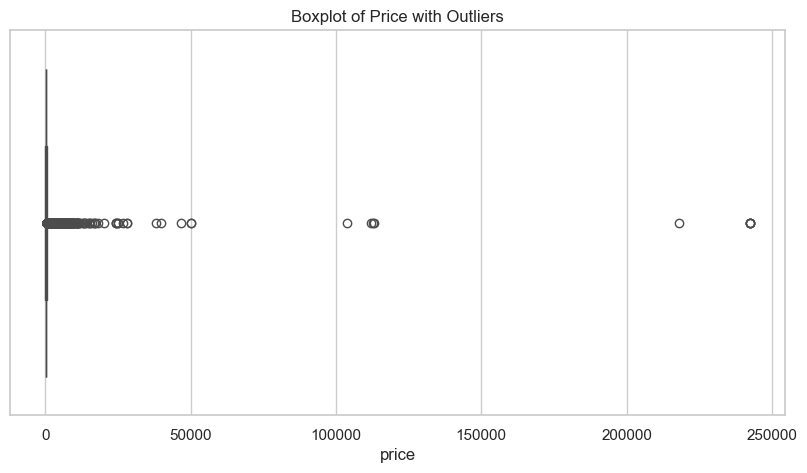

In [227]:
def get_outliers_info(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    
    print(f"Number of outliers: {len(outliers)}")
    
    return outliers, (lower_bound, upper_bound)

price_outliers, bounds = get_outliers_info(df, 'price')

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Price with Outliers')
plt.show()

## New dataframe (deleting outliers)

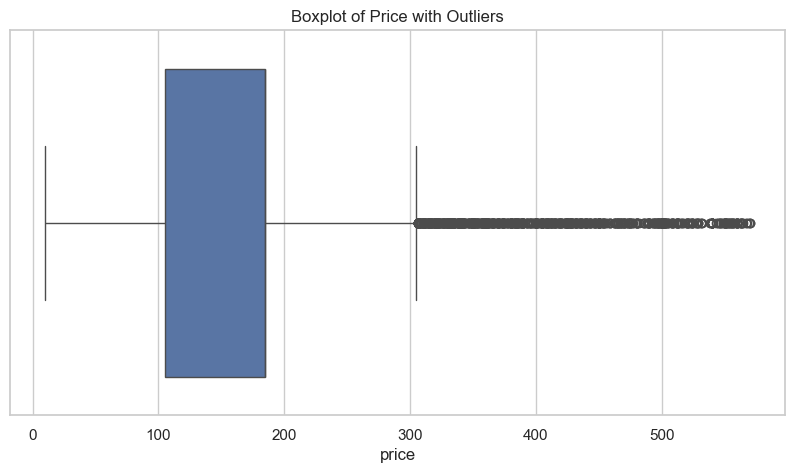

In [228]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

df.to_csv('new_one.csv', index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Price with Outliers')
plt.show()

# Distribution for price and occupancy

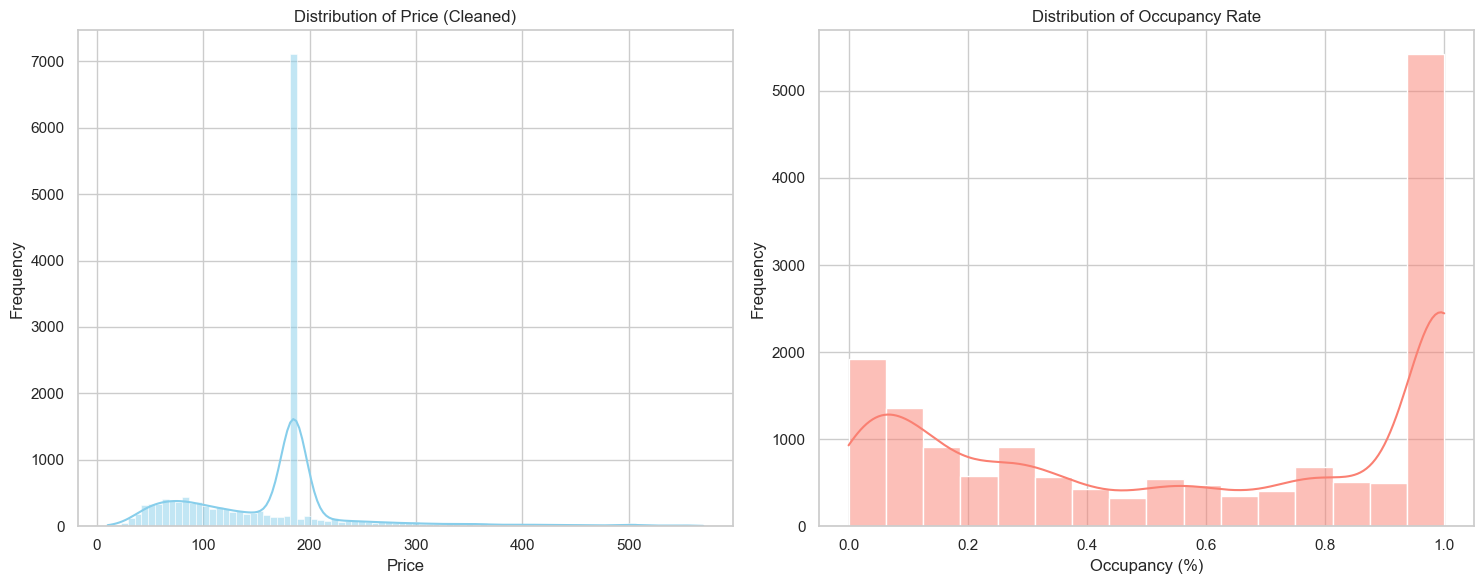

In [229]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Price (Cleaned)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

sns.histplot(df['occupancy'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Occupancy Rate')
axes[1].set_xlabel('Occupancy (%)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Creating linear models and working with assumptions

## Models for price

In [230]:
y = df['price']
cols = ["host_is_superhost", "host_total_listings_count", "host_tenure_days", "accommodates", "bathrooms", "bedrooms", "beds", "availability_365", "number_of_reviews","reviews_last_year", "review_scores_rating", "reviews_per_month", "occupancy"]
X = df[cols].copy()
X = sm.add_constant(X)

price_linlin_model = sm.OLS(y, X).fit()
price_loglin_model = sm.OLS(np.log1p(y), X).fit()
price_linlog_model = sm.OLS(y, np.log1p(X)).fit()
price_loglog_model = sm.OLS(np.log1p(y), np.log1p(X)).fit()

In [231]:
print(price_linlin_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     129.9
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:23:40   Log-Likelihood:                -91791.
No. Observations:               15867   AIC:                         1.836e+05
Df Residuals:                   15853   BIC:                         1.837e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [232]:
print(price_linlog_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     159.6
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:23:40   Log-Likelihood:                -91618.
No. Observations:               15867   AIC:                         1.833e+05
Df Residuals:                   15853   BIC:                         1.834e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [233]:
print(price_loglin_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     189.1
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:23:40   Log-Likelihood:                -11492.
No. Observations:               15867   AIC:                         2.301e+04
Df Residuals:                   15853   BIC:                         2.312e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [234]:
print(price_loglog_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     248.6
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:23:40   Log-Likelihood:                -11164.
No. Observations:               15867   AIC:                         2.236e+04
Df Residuals:                   15853   BIC:                         2.246e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [235]:
threshold = df['price'].median()
y = (df['price'] > threshold).astype(int)

X = df[cols].copy()
X = sm.add_constant(X)

price_probability_model = sm.OLS(y, X).fit()
print(price_probability_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     92.14
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          8.17e-239
Time:                        14:23:40   Log-Likelihood:                -5535.4
No. Observations:               15867   AIC:                         1.110e+04
Df Residuals:                   15853   BIC:                         1.121e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [236]:
price_logit_model = sm.Logit(y, X).fit()
print(price_logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.389233
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  price   No. Observations:                15867
Model:                          Logit   Df Residuals:                    15853
Method:                           MLE   Df Model:                           13
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.07390
Time:                        14:23:40   Log-Likelihood:                -6176.0
converged:                       True   LL-Null:                       -6668.8
Covariance Type:            nonrobust   LLR p-value:                2.163e-202
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -4.0750      1.437     -2.835      0.005      -6.

## Models for occupancy

In [237]:
y = df['occupancy']

cols = ["host_is_superhost", "host_total_listings_count", "host_tenure_days", "accommodates", "bathrooms", "bedrooms", "beds", "availability_365", "number_of_reviews","reviews_last_year", "review_scores_rating", "reviews_per_month", "price"]
X = df[cols].copy()
X = sm.add_constant(X)

occ_linlin_model = sm.OLS(y, X).fit()
occ_loglin_model = sm.OLS(np.log1p(y), X).fit()
occ_linlog_model = sm.OLS(y, np.log1p(X)).fit()
occ_loglog_model = sm.OLS(np.log1p(y), np.log1p(X)).fit()

In [238]:
print(occ_linlin_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 9.470e+05
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:23:40   Log-Likelihood:                 45412.
No. Observations:               15867   AIC:                        -9.080e+04
Df Residuals:                   15853   BIC:                        -9.069e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [239]:
print(occ_linlog_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     4632.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:23:40   Log-Likelihood:                 5047.6
No. Observations:               15867   AIC:                        -1.007e+04
Df Residuals:                   15853   BIC:                            -9960.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [240]:
print(occ_loglin_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 1.737e+05
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:23:40   Log-Likelihood:                 38338.
No. Observations:               15867   AIC:                        -7.665e+04
Df Residuals:                   15853   BIC:                        -7.654e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [241]:
print(occ_loglog_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     3491.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:23:40   Log-Likelihood:                 9663.6
No. Observations:               15867   AIC:                        -1.930e+04
Df Residuals:                   15853   BIC:                        -1.919e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [242]:
threshold = df['occupancy'].median()
y = (df['occupancy'] > threshold).astype(int)

X = df[cols].copy()
X = sm.add_constant(X)

occ_probability_model = sm.OLS(y, X).fit()
print(occ_probability_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     6944.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:23:40   Log-Likelihood:                 3567.8
No. Observations:               15867   AIC:                            -7108.
Df Residuals:                   15853   BIC:                            -7000.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [243]:
occ_logit_model = sm.Logit(y, X).fit()
print(occ_logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.020212
         Iterations 14
                           Logit Regression Results                           
Dep. Variable:              occupancy   No. Observations:                15867
Model:                          Logit   Df Residuals:                    15853
Method:                           MLE   Df Model:                           13
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.9708
Time:                        14:23:40   Log-Likelihood:                -320.70
converged:                       True   LL-Null:                       -10998.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        29.2690      2.228     13.136      0.000      24

# Checking assumptions for models

## Heteroskedasticity

In [244]:
def heteroskedasticity_test(model):
    _, pval, _, _ = het_breuschpagan(model.resid, model.model.exog)
    print(f"p-value = {pval}")
    
    if pval < 0.05:
        print("Heteroskedasticity\n")
    else:
        print("Homoscedasticity\n")

In [245]:
heteroskedasticity_test(price_linlin_model)
heteroskedasticity_test(price_loglin_model)
heteroskedasticity_test(price_linlog_model)
heteroskedasticity_test(price_loglog_model)
heteroskedasticity_test(occ_linlin_model)
heteroskedasticity_test(occ_loglin_model)
heteroskedasticity_test(occ_linlog_model)
heteroskedasticity_test(occ_loglog_model)

p-value = 5.39518426398535e-220
Heteroskedasticity

p-value = 0.0
Heteroskedasticity

p-value = 4.1234455447951604e-190
Heteroskedasticity

p-value = 0.0
Heteroskedasticity

p-value = 0.0004542537444375579
Heteroskedasticity

p-value = 0.0027226649689717996
Heteroskedasticity

p-value = 0.0
Heteroskedasticity

p-value = 0.0
Heteroskedasticity



## Linearity

In [246]:
def linearity_test(model):
    _, pval = sm.stats.linear_rainbow(model)
    print(f"p-value = {pval}")
    
    if pval < 0.05:
        print("Bad linearity\n")
    else:
        print("Good linearity\n")

In [247]:
linearity_test(price_linlin_model)
linearity_test(price_loglin_model)
linearity_test(price_linlog_model)
linearity_test(price_loglog_model)
linearity_test(occ_linlin_model)
linearity_test(occ_loglin_model)
linearity_test(occ_linlog_model)
linearity_test(occ_loglog_model)
linearity_test(price_probability_model)
linearity_test(occ_probability_model)

p-value = 1.3865888127788805e-117
Bad linearity

p-value = 4.4322749221815993e-92
Bad linearity

p-value = 4.510396576852352e-130
Bad linearity

p-value = 1.9371185899269043e-120
Bad linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.003260285369070918
Bad linearity

p-value = 0.04041496435285475
Bad linearity

p-value = 4.074581470843342e-92
Bad linearity

p-value = 0.8902460231102893
Good linearity



## Independance

In [248]:
def durbin_watson_test(model):
    dw_stat = durbin_watson(model.resid)
    print(f"DW = {dw_stat}")
    if dw_stat < 1.5:
        print("Positive\n")
    elif dw_stat > 2.5:
        print("Negative\n")
    else:
        print("No autocorrelation\n")

In [249]:
durbin_watson_test(price_linlin_model)
durbin_watson_test(price_loglin_model)
durbin_watson_test(price_linlog_model)
durbin_watson_test(price_loglog_model)
durbin_watson_test(occ_linlin_model)
durbin_watson_test(occ_loglin_model)
durbin_watson_test(occ_linlog_model)
durbin_watson_test(occ_loglog_model)
durbin_watson_test(price_probability_model)
durbin_watson_test(occ_probability_model)

DW = 1.7302880701098535
No autocorrelation

DW = 1.6328877199786445
No autocorrelation

DW = 1.751980823265965
No autocorrelation

DW = 1.6433689439441175
No autocorrelation

DW = 1.9997153519117745
No autocorrelation

DW = 1.958041408741534
No autocorrelation

DW = 1.947856749760284
No autocorrelation

DW = 1.9518638809266298
No autocorrelation

DW = 1.8047250599822109
No autocorrelation

DW = 2.0114185280592722
No autocorrelation



## Normality

In [250]:
def jarque_bera_test(model):
    jb_stat, jb_pval, _, _ = sm.stats.jarque_bera(model.resid)
    print(f"JB = {jb_stat}, p-value = {jb_pval}")
    
    if jb_pval < 0.05:
        print("Non-normality\n")
    else:
        print("Normality\n")

In [251]:
jarque_bera_test(price_linlin_model)
jarque_bera_test(price_loglin_model)
jarque_bera_test(price_linlog_model)
jarque_bera_test(price_loglog_model)
jarque_bera_test(occ_linlin_model)
jarque_bera_test(occ_loglin_model)
jarque_bera_test(occ_linlog_model)
jarque_bera_test(occ_loglog_model)

JB = 28326.352197780394, p-value = 0.0
Non-normality

JB = 1746.9242897937368, p-value = 0.0
Non-normality

JB = 29656.022402979954, p-value = 0.0
Non-normality

JB = 1244.4886666840682, p-value = 5.79054757326433e-271
Non-normality

JB = 6377957874.895912, p-value = 0.0
Non-normality

JB = 8896920.631020872, p-value = 0.0
Non-normality

JB = 1079.9009903735655, p-value = 3.1803831177589986e-235
Non-normality

JB = 777.5597209234136, p-value = 1.4290648142495337e-169
Non-normality



## Assumptions for logit model

In [252]:
print(price_logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                  price   No. Observations:                15867
Model:                          Logit   Df Residuals:                    15853
Method:                           MLE   Df Model:                           13
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.07390
Time:                        14:23:40   Log-Likelihood:                -6176.0
converged:                       True   LL-Null:                       -6668.8
Covariance Type:            nonrobust   LLR p-value:                2.163e-202
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -4.0750      1.437     -2.835      0.005      -6.892      -1.258
host_is_superhost             0.1553      0.057      2.747      0.006       0.044     

In [253]:
print(occ_logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:              occupancy   No. Observations:                15867
Model:                          Logit   Df Residuals:                    15853
Method:                           MLE   Df Model:                           13
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.9708
Time:                        14:23:40   Log-Likelihood:                -320.70
converged:                       True   LL-Null:                       -10998.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        29.2690      2.228     13.136      0.000      24.902      33.636
host_is_superhost            -0.1301      0.228     -0.571      0.568      -0.577     

### Model significance

In [254]:
price_pval = price_logit_model.llr_pvalue
occ_pval = occ_logit_model.llr_pvalue

alpha = 0.05
def significance_test(pval, model_name):
    if pval < alpha:
        print(f"{model_name}: Model is significant, p-value = {pval}")
    else:
        print(f"{model_name}: Model is not significant, p-value = {pval}")

significance_test(price_pval, "PRICE model")
significance_test(occ_pval, "OCC model")

PRICE model: Model is significant, p-value = 2.1625482732228663e-202
OCC model: Model is significant, p-value = 0.0


### Pseudo $R^2$

In [255]:
price_r2 = price_logit_model.prsquared
occ_r2 = occ_logit_model.prsquared

def interpret_r2(r2, model_name):
    if r2 < 0.2:
        quality = "weak"
    elif r2 < 0.4:
        quality = "moderate"
    else:
        quality = "strong"

    print(f"{model_name}: quality of model — {quality} (Pseudo R² = {r2:.3f})")

interpret_r2(price_r2, "PRICE model")
interpret_r2(occ_r2, "OCC model")

PRICE model: quality of model — weak (Pseudo R² = 0.074)
OCC model: quality of model — strong (Pseudo R² = 0.971)
